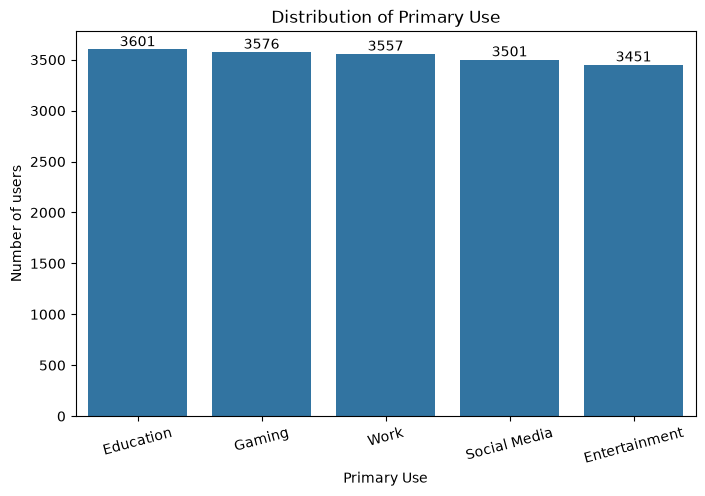

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/phone_usage_india.csv")

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Primary Use",
    order=df["Primary Use"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribution of Primary Use")
plt.xlabel("Primary Use")
plt.ylabel("Number of users")

plt.xticks(rotation=15)

plt.show()

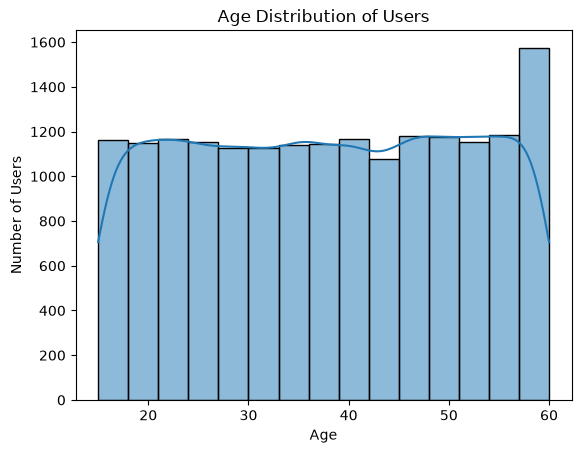

In [21]:
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

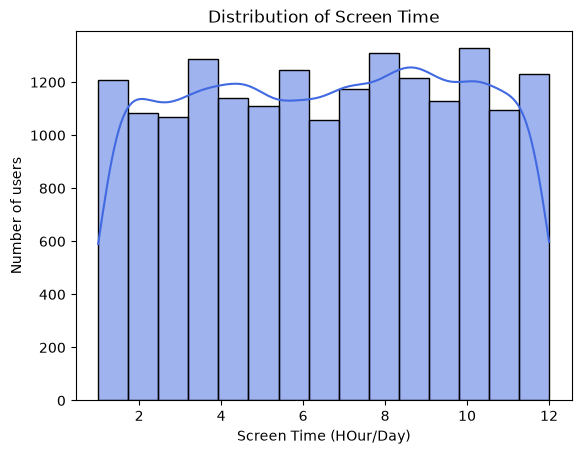

In [22]:
sns.histplot(
    data=df,
    x="Screen Time (hrs/day)",
    bins=15,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Screen Time")
plt.xlabel("Screen Time (HOur/Day)")
plt.ylabel("Number of users")

plt.show()

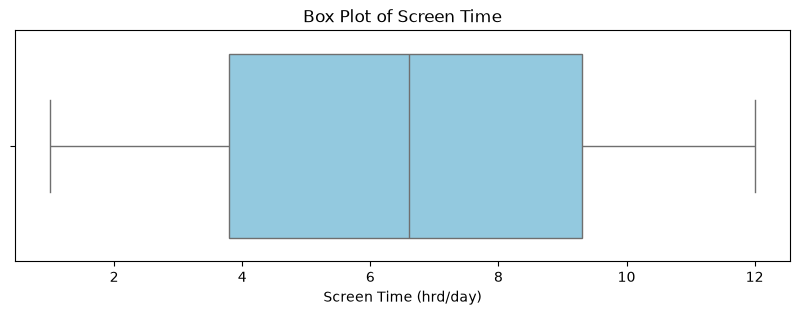

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("../data/phone_usage_india.csv") 
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["Screen Time (hrs/day)"],
    color="skyblue"
)

plt.title("Box Plot of Screen Time")
plt.xlabel("Screen Time (hrd/day)")

plt.show()


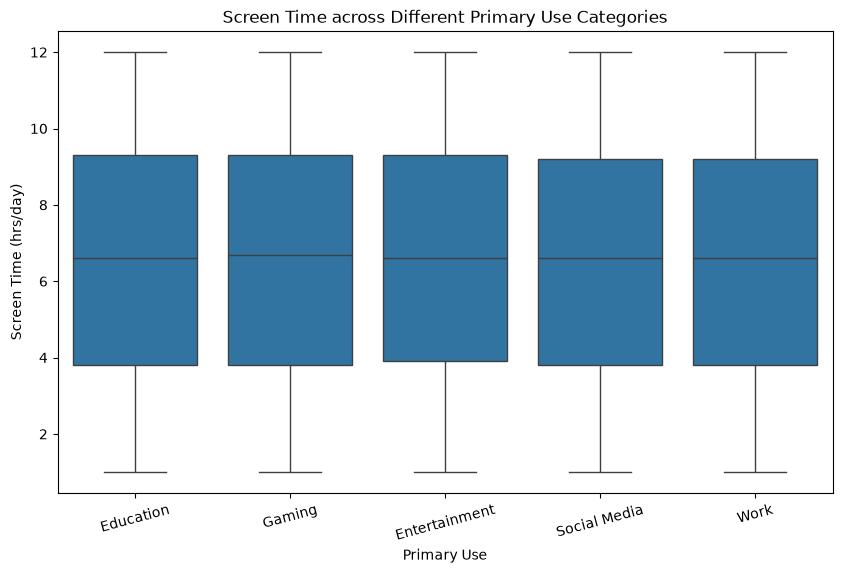

In [24]:
# Relation b/w Primary Use and Screen Time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("../data/phone_usage_india.csv") 
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Primary Use",
    y="Screen Time (hrs/day)"
)

plt.title("Screen Time across Different Primary Use Categories")
plt.xlabel("Primary Use")
plt.ylabel("Screen Time (hrs/day)")

plt.xticks(rotation=15)

plt.show()

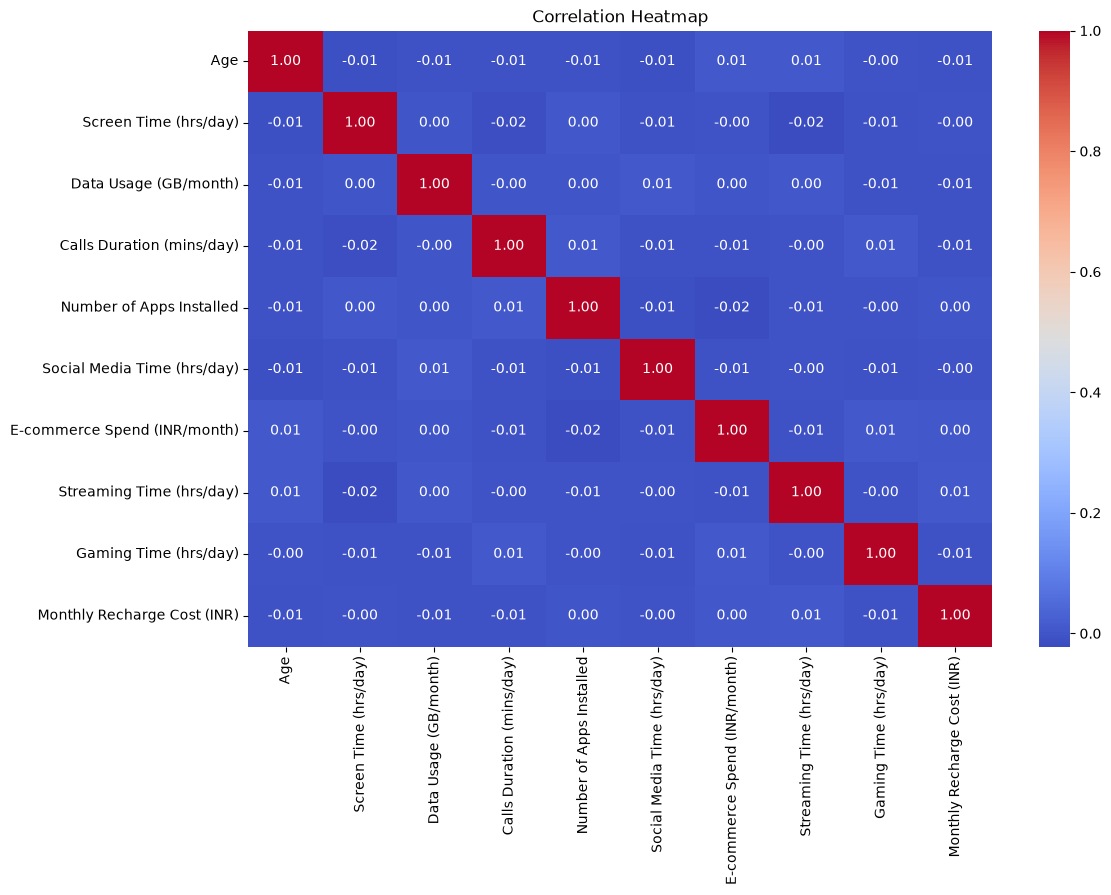

In [25]:
#Correlation Analysis (Understanding Relationships Between Numerical Features)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("../data/phone_usage_india.csv") 
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
#Feature Engineering and Data Preprocessing(Machine Learning)

#Remove User ID
import pandas as pd

df = pd.read_csv("../data/phone_usage_india.csv")

df = df.drop(columns=["User ID"])
#print(df.head())

In [27]:
#Features
X = df.drop("Primary Use", axis=1)
#print(x.head())
#print(df.head())

#Target
y = df["Primary Use"]

print("X Shape:",X.shape)
print("Y Shape:",y.shape)

print("\nFeatures:",X.columns.tolist())
print("\nTarget:",y.name)

X Shape: (17686, 14)
Y Shape: (17686,)

Features: ['Age', 'Gender', 'Location', 'Phone Brand', 'OS', 'Screen Time (hrs/day)', 'Data Usage (GB/month)', 'Calls Duration (mins/day)', 'Number of Apps Installed', 'Social Media Time (hrs/day)', 'E-commerce Spend (INR/month)', 'Streaming Time (hrs/day)', 'Gaming Time (hrs/day)', 'Monthly Recharge Cost (INR)']

Target: Primary Use


In [28]:
#Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check Unique Values in Each Column
print("\nUnique Values:")
print(df.nunique())


Missing Values:
Age                             0
Gender                          0
Location                        0
Phone Brand                     0
OS                              0
Screen Time (hrs/day)           0
Data Usage (GB/month)           0
Calls Duration (mins/day)       0
Number of Apps Installed        0
Social Media Time (hrs/day)     0
E-commerce Spend (INR/month)    0
Streaming Time (hrs/day)        0
Gaming Time (hrs/day)           0
Monthly Recharge Cost (INR)     0
Primary Use                     0
dtype: int64

Duplicate Rows:
0

Unique Values:
Age                               46
Gender                             3
Location                          10
Phone Brand                       10
OS                                 2
Screen Time (hrs/day)            111
Data Usage (GB/month)            491
Calls Duration (mins/day)       2945
Number of Apps Installed         191
Social Media Time (hrs/day)       56
E-commerce Spend (INR/month)    8202
Streaming Time (hr

In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load Dataset
df = pd.read_csv("../data/phone_usage_india.csv")

# Remove User ID
df = df.drop("User ID", axis=1)

# Separate Features and Target
X = df.drop("Primary Use", axis=1)
y = df["Primary Use"]

# Encode Target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(Y)

# Encode Feature Columns
X = pd.get_dummies(
    X,
    columns=["Gender", "Location", "Phone Brand", "OS"],
    drop_first=True
)

print("Encoded Feature Shape:", X.shape)
print("\nFirst 5 Rows:")
print(X.head())

print("\nEncoded Target Classes:")
print(label_encoder.classes_)

Encoded Feature Shape: (17686, 31)

First 5 Rows:
   Age  Screen Time (hrs/day)  Data Usage (GB/month)  \
0   53                    3.7                   23.9   
1   60                    9.2                   28.1   
2   37                    4.5                   12.3   
3   32                   11.0                   25.6   
4   16                    2.2                    2.5   

   Calls Duration (mins/day)  Number of Apps Installed  \
0                       37.9                       104   
1                       13.7                       169   
2                       66.8                        96   
3                      156.2                       146   
4                      236.2                        86   

   Social Media Time (hrs/day)  E-commerce Spend (INR/month)  \
0                          3.9                           469   
1                          2.8                          4997   
2                          3.0                          2381   
3       

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42 
)

print("Training Faetures Shape:", x_train.shape)
print("Testing Features Shape:", x_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Faetures Shape: (14148, 31)
Testing Features Shape: (3538, 31)
Training Target Shape: (14148,)
Testing Target Shape: (3538,)
